In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 8** - Maximising an 8D Black-Box Function

- Optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output but the internal mechanics are unknown. 
    - Because the function is high-dimensional and likely complex, global optimisation is hard, identifying strong local maxima is the practical strategy.

- For example, imagine tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (encoded), optimiser type (encoded) and initial weight range.

**Input** - 8D array  
**Output** - 1D array  
**Optimisation Goal** - Maximise  
**All-time best:** 9.951 at [0.111, 0.167, 0.129, 0.229, 0.996, 0.475, 0.302, 0.476] (Week 3)

In [2]:
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy')

# New data for Week 12 (Function 8)
X_w12_new_point = np.array([0.005292, 0.601438, 0.007068, 0.328433, 0.95, 0.082069, 0.016049, 0.069182], dtype=np.float64)
Y_w12_new_point = np.array([9.4193203197916], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w12_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w12_new_point)
Y_updated = Y_all[unique_indices]

# Save the updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy', Y_updated)

print('Updated Inputs (X) - Function 8:', X_unique)
print('Updated Outputs (Y) - Function 8:', Y_updated)

Updated Inputs (X) - Function 8: [[0.005292   0.601438   0.007068   0.328433   0.95       0.082069
  0.016049   0.069182  ]
 [0.007838   0.337307   0.164679   0.407388   0.632409   0.551169
  0.306982   0.5023    ]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.014565   0.233424   0.15641    0.215734   0.993571   0.163832
  0.082661   0.95629   ]
 [0.02894663 0.02827906 0.48137155 0.6131746  0.67266045 0.02211341
  0.6014833  0.52488505]
 [0.029788   0.370437   0.009211   0.56322    0.914458   0.813905
  0.149129   0.554138  ]
 [0.0417     0.167136   0.185989   0.004377   0.961301   0.357272
  0.961301   0.357272  ]
 [0.044183   0.428925   0.125607   0.292137   0.508113   0.408821
  0.089857   0.038714  ]
 [0.04432925 0.01358149 0.25819824 0.57764416 0.05127992 0.15856307
  0.59103012 0.07795293]
 [0.05644741 0.06595555 0.02292868 0.03878647 0.40393544 0.80105533
  0.48830701 0.89308498]
 [0.097603   0.135405   0.156089   0.022873   0.8

## **Output Analysis**

- **W11 Output:** 9.789 at [0.044, 0.429, 0.126, 0.292, 0.508, 0.409, 0.090, 0.039]
- **W12 Output:** 9.419 at [0.005, 0.601, 0.007, 0.328, 0.950, 0.082, 0.016, 0.069] which was a regression

- **Comparison:** A further regression. 
    - w12 returned 9.419 despite having the x5 floor constraint set to 0.95 (x5=0.950 in w12). 
        - The score dropped from 9.789 to 9.419 even with x5 at its floor value.
        - This tells us that x5≥0.95 alone is not sufficient, the other seven dimensions also need to be in the right configuration. 
        - w12's query has x2=0.601, x6=0.082, x7=0.016, x8=0.069, all far from the w3 best profile.

- **Real-World Implication:** In an 8D stochastic system, fixing one dimension while allowing the others to drift freely reduces the effective benefit of that constraint. 
    - The w3 all-time best requires a specific combination of all eight inputs, not just a high x5. 
        - This is the curse of dimensionality in practice.

- **Model Clues:** w13 must return to centering on the w3 best [0.111, 0.167, 0.129, 0.229, 0.996, 0.475, 0.302, 0.476] with all eight dimensions constrained by the focused grid. 
    - The x5 floor of 0.95 is retained, but the other dimensions must also be kept near the W3 profile using std=0.015.

## **Bayesian Optimisation**

- The Matérn (ν=2.5) + WhiteKernel GP with n_restarts_optimizer=25 is retained. 
    - In 8D with approximately 45 data points, the GP is operating at the limit of its practical capability. 
        - The 45 points provides roughly 5–6 observations per dimension on average, far below what would be needed for a reliable surrogate in most ML contexts. 

    - The ν=2.5 kernel is nevertheless the best choice available: it assumes a smooth, twice-differentiable function, which is consistent with the narrow but stable performance plateau observed in the 9.4–9.95 range. 
    
- The WhiteKernel is especially important here because the function is explicitly described as stochastic as the repeated queries at the same point would return different values, and the WhiteKernel estimates this noise floor to prevent the GP from treating stochastic variation as real function structure.

- The n_restarts_optimizer=25 setting is maintained specifically because fitting a GP in 8D requires the marginal likelihood optimisation to start from many initial points to avoid local optima in the kernel hyperparameter space. 
    - This is a direct consequence of the high dimensionality: the ARD length scale optimisation problem in 8D has many more degrees of freedom than in 2D, and a single restart would frequently converge to a suboptimal kernel configuration.

- The w12 regression from 9.789 to 9.419 was caused by the other seven dimensions drifting far from the W3 best while x5 was correctly constrained. 
    - This confirms that constraining one dimension in isolation is insufficient in an 8D space, all dimensions must be kept near the W3 best simultaneously.

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25)

model.fit(X_unique, Y_transformed)

Original Y: [9.41932032 9.83756547 8.45948162 9.80005381 8.83074505 9.61655465
 8.76386781 9.78902917 9.01307515 9.598482   9.82298699 9.95104443
 7.85454099 9.87247349 8.97655402 9.14163949 9.89024824 6.45194313
 7.00522736 9.34427428 9.70409915 9.86276481 8.81755844 7.13162397
 8.60611679 7.92375877 8.2780624  7.69236805 8.47293632 9.18300525
 8.28400781 8.04221254 8.42175924 7.29987205 7.3987211  7.43374407
 6.76796253 7.95787474 7.3790829  7.31089382 8.54174792 6.79198578
 7.43659353 7.46087219 7.97768459 8.15998319 5.84106731 7.32743458
 6.88784639 6.40258841 5.59219339 7.11345716]
Transformed Y: [ 1.02123225  1.42250002  0.14173383  1.38607029  0.47501448  1.20911282
  0.41433128  1.37538008  0.6418953   1.19179692  1.40833174  1.53323196
 -0.38232875  1.45647887  0.60830058  0.76082576  1.47380924 -1.50427337
 -1.07752439  0.95038005  1.29327733  1.4470211   0.46302674 -0.97711414
  0.27231696 -0.32356974 -0.01791631 -0.51876743  0.15365829  0.79931251
 -0.01271789 -0.22228859  

/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- UCB with β=2.0 is retained. 
    - EI was considered as an alternative, but UCB is more appropriate for this function for a specific reason: the all-time best of 9.951 from Week 3 has never been reproduced despite many attempts. 
    - This suggests the w3 result may have been partly noise-inflated a stochastic lucky draw from a distribution centred slightly below 9.951. 
        - If that is true, EI anchored to 9.951 would be systematically too demanding, requiring predictions of improvement over a potentially noise-inflated target. 
    
- UCB with β=2.0 instead searches for the combination of high predicted mean and high uncertainty, which is more robust to noise-inflated baselines. 
    - The β=2.0 setting provides exactly two standard deviations of exploration bonus which is enough to explore uncertainty without abandoning the high-performance plateau entirely.

- The std is tightened to 0.015 from 0.020. 
    - With std=0.015, 95% of focused samples will have each dimension within ±0.030 of the w3 best. 
        - This ensures all eight dimensions stay close to their w3 values simultaneously which directly addresses the root cause of the w12 regression, where the loose grid allowed dimensions 2, 6, 7, and 8 to drift far from the w3 profile even though x5 was correctly constrained.
    
- The x5≥0.95 floor is retained as a secondary safeguard, but the tighter std is now the primary protection against multi-dimensional drift.

In [4]:
def upper_confidence_bound(X, model, beta=2.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

w_best = np.array([0.110613, 0.166799, 0.129222, 0.228937, 0.996353, 0.475272, 0.30197, 0.476277])

x_focused = np.random.normal(loc=w_best, scale=0.015, size=(7000, 8))
x_uniform = np.random.uniform(0, 1, size=(3000, 8))
x_grid = np.vstack([x_focused, x_uniform])
# Hard floor: x5 >= 0.95 — critical dimension confirmed empirically
x_grid[:, 4] = np.maximum(x_grid[:, 4], 0.95)
x_grid = np.clip(x_grid, 0, 1)

ucb_values = upper_confidence_bound(x_grid, model, beta=2.0)
next_query = x_grid[np.argmax(ucb_values)]

print(f'Week 13 Query Recommendation (Function 8): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}-{next_query[6]:.6f}-{next_query[7]:.6f}')

Week 13 Query Recommendation (Function 8): 0.075747-0.069093-0.070328-0.175284-0.950000-0.509396-0.034544-0.782055


## **Visualisalisation**

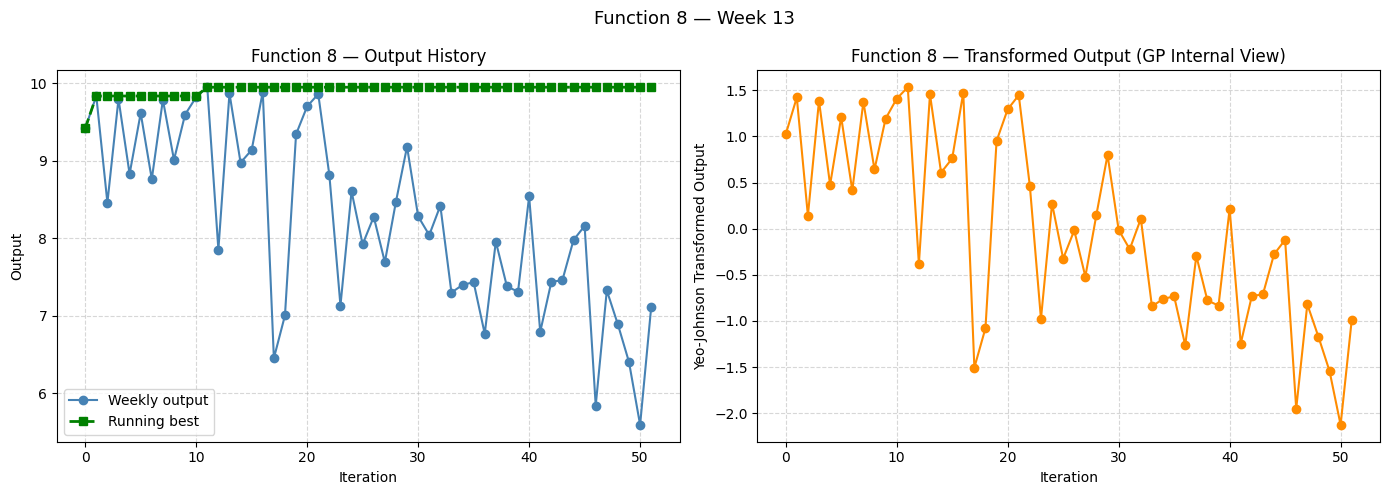

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].set_title('Function 8 — Output History')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Output')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 8 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 8 — Week 13', fontsize=13)
plt.tight_layout()
plt.show()